# Exercises - Solvers

_______

We want to solve  $S(x) = Kx-F = 0$, which is linear but we don't want to use the matrix inverse.

### a) Fixed point

1. Write $S(x) = 0$ under the form $F(x) = x$

2. Try to solve the problem with a fixed point algorithm for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a,b >0$
3. Try to solve the problem with a fixed point for $K = \begin{bmatrix} a, 0\\ 0, b \end{bmatrix}$ with $a>0$ and $b<0$.
4. Interpretation?
5. Would Newton method, which is a special kind of fixed point, work on this problem?

In [7]:
import numpy as np
import matplotlib.pyplot as plt

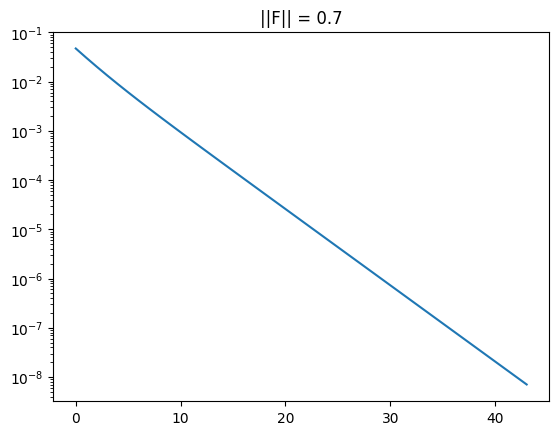

In [ ]:
def fixedPoint(F, x0, maxit = 100, tol = 1e-8):
    x = [x0]
    for _ in range(maxit):
        x.append(F(x[-1]))
        if np.linalg.norm(x[-1]-x[-2]) < tol:
            break
    return x


th = np.random.rand()
R = np.array([[np.cos(th), -np.sin(th)],[np.sin(th), np.cos(th)]])

K = R @ np.array([[3,0],[0,4]]) @ R.T
f = np.random.rand(2)

S = lambda x: K @ x - f
a = 0.1
F = lambda X : X - a * S(X)
x0 = np.array([0,0])
F(x0)
x = fixedPoint(F, x0)
plt.semilogy([np.linalg.norm(x[i+1] - x[i]) for i in range(len(x)-1)])
plt.title(f"||F|| = {max(abs(np.linalg.eig(np.eye(2) - a*K)[0]))}")
plt.show()


### b) Newton

NameError: name 'f2' is not defined

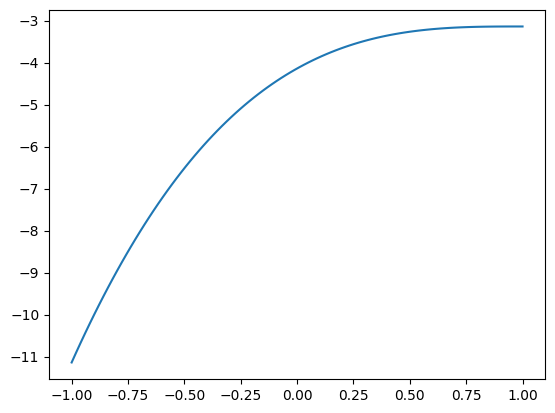

In [9]:
def f1(x):
    return (x-1)**3 - np.pi


X = np.linspace(-1,1,100)
plt.plot(X, f1(X))
plt.plot(X,f2(X))
plt.grid()

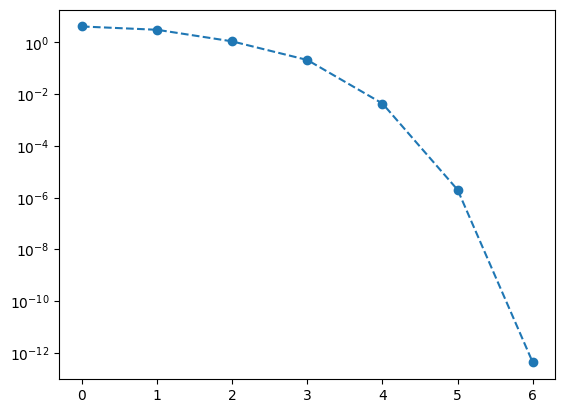

In [ ]:
def naiveNewton(S, x0 = 0, maxit = 100, tol = 1e-8):
    x = [x0]
    for _ in range(maxit):
        d = -cplxStep(S, x[-1], h = 1e-50) * S(x[-1])
        x.append(x[-1] + d)
        if abs(S(x[-1]))<tol:
            break
    return x

def lineSearch_newton(residual, dresidual, B0,
           alpha = 0.5, s = 0.1, maxit_linesearch = 10,   # linesearch
           maxit = 100, rtol = 1e-8, atol = 1e-8   # stop criterion
           ):
     """ Newton method with Armijo's linesearch"""
     
     res2 = lambda B : residual(B)**2
     B = [B0]
     res0 = residual(B[0])
     k = 0 
     while abs(residual(B[-1])) > atol \
           and abs(residual(B[-1])/res0) > rtol \
           and k < maxit:
          
        # Descent direction
        d = - dresidual(B[-1]) ** (-1) * residual(B[-1]) ;  

        # Line search (Armijo backtracking)
        i = 0
        res2B = res2(B[-1])
        while res2(B[-1] + alpha ** i * d) >= ( 1 - 2*s*alpha ** i ) * res2B:
            if i>maxit_linesearch: 
                raise Exception("Linesearch has failed after {maxit_linesearch} iterations.")
            i += 1

        B.append(B[-1] +  alpha ** i * d)
        k += 1
        
     return np.array(B)


#xNewton1 = naiveNewton(f1, 0)
#plt.semilogy([abs(f1(xx)) for xx in xNewton1], 'o--', label = "naive")

xNewton2 = lineSearch_newton(f1, lambda x: cplxStep(f1, x, 1e-50), 0)
plt.semilogy([abs(f1(xx)) for xx in xNewton2], 'o--', label = "linesearch")

plt.show()


In [ ]:
(xNewton2[-1]-1)**3 - np.pi

NameError: name 'xNewton2' is not defined